# Temperature Prediction  



## 1. Load Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


In [32]:
# Load the weather history dataset
df = pd.read_csv('Data/weatherHistory.csv')

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully
Shape: (96453, 12)

First few rows:


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [33]:
# Check data types  
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB
None


In [34]:
# Check for missing values
print("Missing Values Count:")
missing_values = df.isnull().sum()
print(missing_values)
print("Missing Values Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))

Missing Values Count:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64
Missing Values Percentage:
Formatted Date              0.00
Summary                     0.00
Precip Type                 0.54
Temperature (C)             0.00
Apparent Temperature (C)    0.00
Humidity                    0.00
Wind Speed (km/h)           0.00
Wind Bearing (degrees)      0.00
Visibility (km)             0.00
Loud Cover                  0.00
Pressure (millibars)        0.00
Daily Summary               0.00
dtype: float64


In [35]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


## 2. Data Cleaning

### 2.1 Remove Duplicates

In [36]:
df_clean = df.copy()

# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")
    
print(f"\nShape after removing duplicates: {df_clean.shape}")

Number of duplicate rows: 24
Removed 24 duplicate rows

Shape after removing duplicates: (96429, 12)


### 2.2 Handle Missing Values 

In [37]:
# Check the percentage of missing Precip Type values
missing_percentage = (df_clean['Precip Type'].isnull().sum() / len(df_clean)) * 100
print(f"Missing Precip Type: {missing_percentage:.2f}% of data")

# If less than 1%, drop the missing values
if missing_percentage < 1:
    print("\nSince missing values are less than 1%, we can safely drop them.")
    df_clean = df_clean.dropna(subset=['Precip Type'])
    print(f"New shape after dropping missing values: {df_clean.shape}")

print(f"\nFinal missing values check:")
print(df_clean.isnull().sum())

Missing Precip Type: 0.54% of data

Since missing values are less than 1%, we can safely drop them.
New shape after dropping missing values: (95912, 12)

Final missing values check:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


### 2.3 Verify Data Quality After Cleaning

In [38]:

print("FINAL CLEANED DATASET")
print(f"Shape: {df_clean.shape}")
print(f"\nData Types:")
print(df_clean.dtypes)
print(f"\nMissing Values:")
print(df_clean.isnull().sum().sum(), "total missing values")
print(f"\nPrecip Type Distribution (after cleaning):")
print(df_clean['Precip Type'].value_counts())

FINAL CLEANED DATASET
Shape: (95912, 12)

Data Types:
Formatted Date               object
Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object

Missing Values:
0 total missing values

Precip Type Distribution (after cleaning):
Precip Type
rain    85200
snow    10712
Name: count, dtype: int64


### 2.4 Data Type Conversion

#### 2.4.1 Convert Formatted Date to Datetime

In [39]:
# Convert Formatted Date from string to datetime
print("Before conversion:")
print(f"Data type: {df_clean['Formatted Date'].dtype}")

# Convert to datetime
df_clean['Formatted Date'] = pd.to_datetime(df_clean['Formatted Date'], utc=True)

print("\n" + "="*10)
print("After conversion:")
print(f"Data type: {df_clean['Formatted Date'].dtype}")


Before conversion:
Data type: object

After conversion:
Data type: datetime64[ns, UTC]


#### 2.4.2 Verify and Categorize All Column Types

In [40]:

print(df_clean.dtypes)

# Categorize columns
datetime_cols = df_clean.select_dtypes(include=['datetime64']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\n datetime ({len(datetime_cols)}):")
for col in datetime_cols:
    print(f"   - {col}")

print(f"\n numerical ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"   - {col}")
    
print(f"\n Categorical  ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"   - {col}")



Formatted Date              datetime64[ns, UTC]
Summary                                  object
Precip Type                              object
Temperature (C)                         float64
Apparent Temperature (C)                float64
Humidity                                float64
Wind Speed (km/h)                       float64
Wind Bearing (degrees)                  float64
Visibility (km)                         float64
Loud Cover                              float64
Pressure (millibars)                    float64
Daily Summary                            object
dtype: object

 datetime (0):

 numerical (8):
   - Temperature (C)
   - Apparent Temperature (C)
   - Humidity
   - Wind Speed (km/h)
   - Wind Bearing (degrees)
   - Visibility (km)
   - Loud Cover
   - Pressure (millibars)

 Categorical  (3):
   - Summary
   - Precip Type
   - Daily Summary


#### 2.4.3 Convert Categorical Columns to Category Type and Drop Loud Cover

In [41]:
# dropping loud cover as it has only one value (only zero) 
df_clean.drop('Loud Cover', axis=1, inplace=True)
# Convert categorical columns to 'category' type for better memory usage
categorical_columns = ['Summary', 'Precip Type', 'Daily Summary']

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype('category')

print(df_clean.dtypes)


Formatted Date              datetime64[ns, UTC]
Summary                                category
Precip Type                            category
Temperature (C)                         float64
Apparent Temperature (C)                float64
Humidity                                float64
Wind Speed (km/h)                       float64
Wind Bearing (degrees)                  float64
Visibility (km)                         float64
Pressure (millibars)                    float64
Daily Summary                          category
dtype: object


## 3. EDA

### 3.1 Univariate analysis

#### 3.1.1 Checking for Skewness of the Data

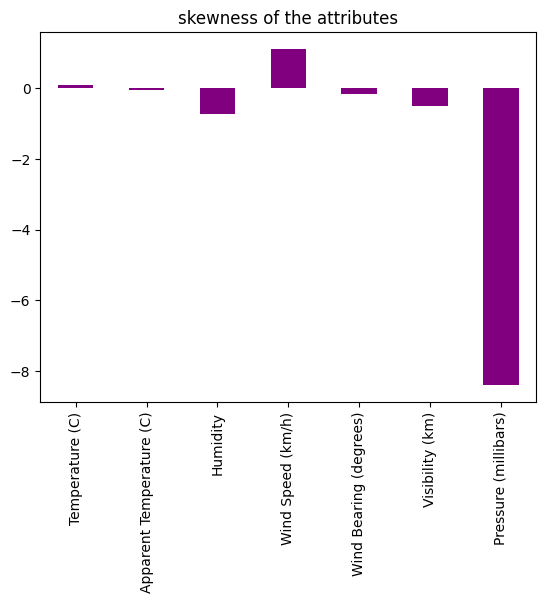

In [42]:
# checking for skewness of the data 
df_clean.select_dtypes(include=[np.number]).skew().plot(kind='bar', color='purple')
plt.title('skewness of the attributes')
plt.show()

#### 3.1.2 Checking for Outliers Through Boxplot

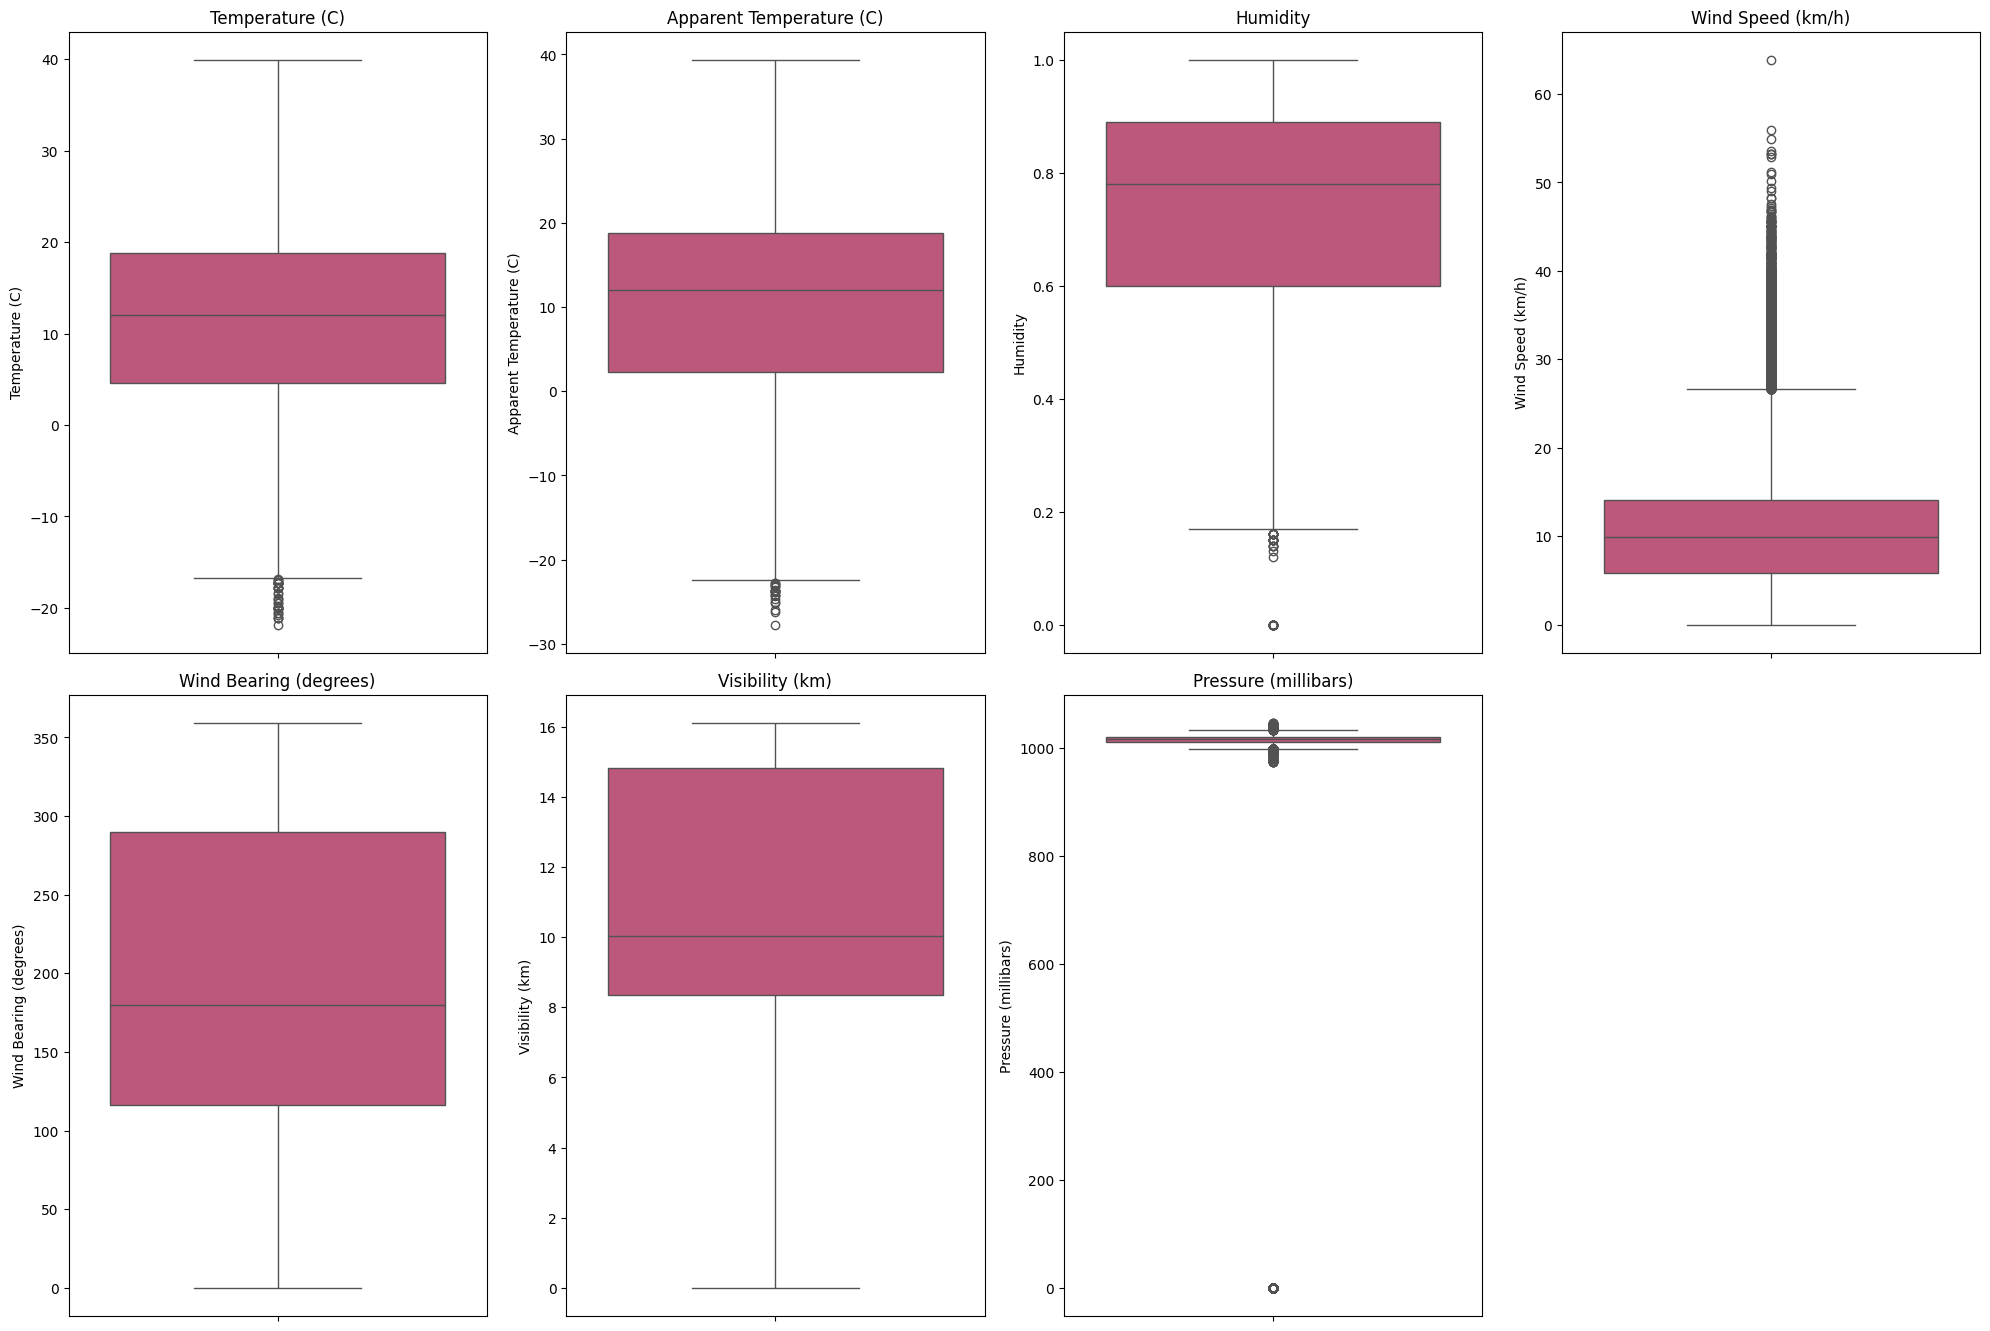

In [43]:
# checking for outliers through boxplot 

plt.figure(figsize=(20,20))

re=1
for i in df_clean.select_dtypes(include=[np.number]).columns:
    plt.subplot(3,4,re)
    sns.boxplot(df_clean[i], palette='plasma')
    plt.title(i)
    re+=1
plt.tight_layout()
plt.show()

**Observation:** Outliers are present in Temperature, Apparent Temperature, Humidity, and Wind Speed.

### 3.1.3 Explore Summary Column

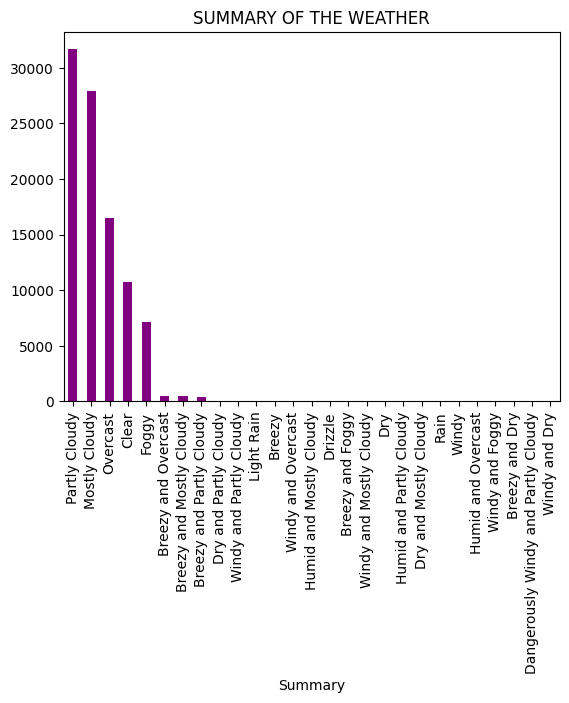

In [44]:
df_clean['Summary'].value_counts().plot(kind='bar', color='purple')
plt.title('SUMMARY OF THE WEATHER')
plt.show()


**Observation:** In the given dataset, most of the days are partly cloudy, followed by mostly cloudy, overcast, and foggy

In [45]:
df_clean['Daily Summary'].value_counts() 

Daily Summary
Mostly cloudy throughout the day.         20020
Partly cloudy throughout the day.          9930
Partly cloudy until night.                 6169
Partly cloudy starting in the morning.     5177
Foggy in the morning.                      4201
                                          ...  
Rain until afternoon.                        17
Rain until morning.                          12
Light rain in the morning.                   11
Drizzle starting in the evening.              9
Light rain overnight.                         3
Name: count, Length: 214, dtype: int64

#### Note on 'Daily Summary' Column

- The **'Daily Summary'** column is more like a description of the day.  
- Proper analysis would require **NLP techniques**.  
- Therefore, this column is **dropped from the dataframe**.


In [46]:
df_clean.drop('Daily Summary', axis=1, inplace=True)

### 3.1.4 Checking precipitation type

In [47]:
# checking precipitation type
df_clean['Precip Type'].unique()

['rain', 'snow']
Categories (2, object): ['rain', 'snow']

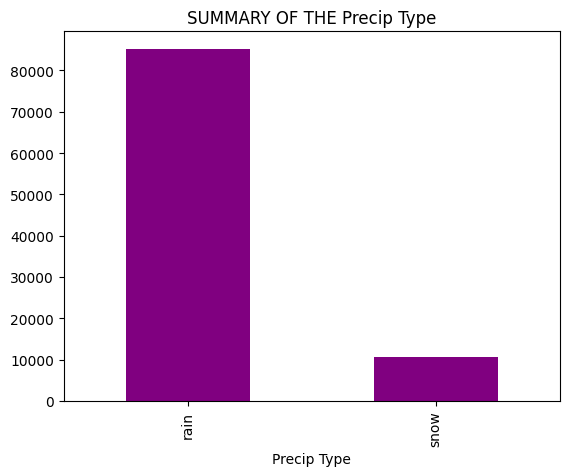

In [48]:
df_clean['Precip Type'].value_counts().plot(kind='bar', color='purple')
plt.title('SUMMARY OF THE Precip Type')
plt.show()


**Observation:** The given dataset has only two kinds of precipitation: rain and snow. Among these, most of the days experienced rain.

### 3.2 Bivariate analysis

### 3.2.1 Summary vs Precipitation Type

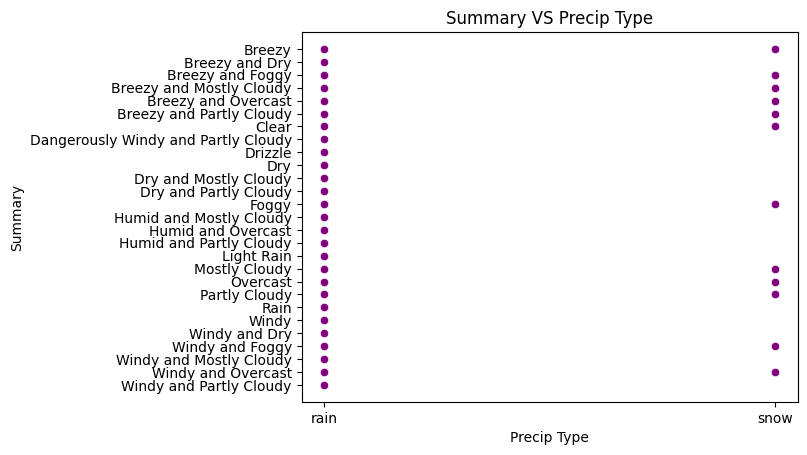

In [49]:
sns.scatterplot(y=df_clean['Summary'], x=df_clean['Precip Type'], color='Purple')
plt.title('Summary VS Precip Type')
plt.show()

#### Observation on Precipitation Types

- **Rain:**  
  - Can occur under all types of weather in the dataset.

- **Snow:**  
  - Only observed under specific conditions: cloudy, foggy, or windy days.


### 3.2.2 Precipitation type vs other variables

In [50]:
# Precip Type with all other numerical variables
df_new_num=df_clean.drop(['Formatted Date','Summary','Precip Type' ], axis=1)
df_new_num.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


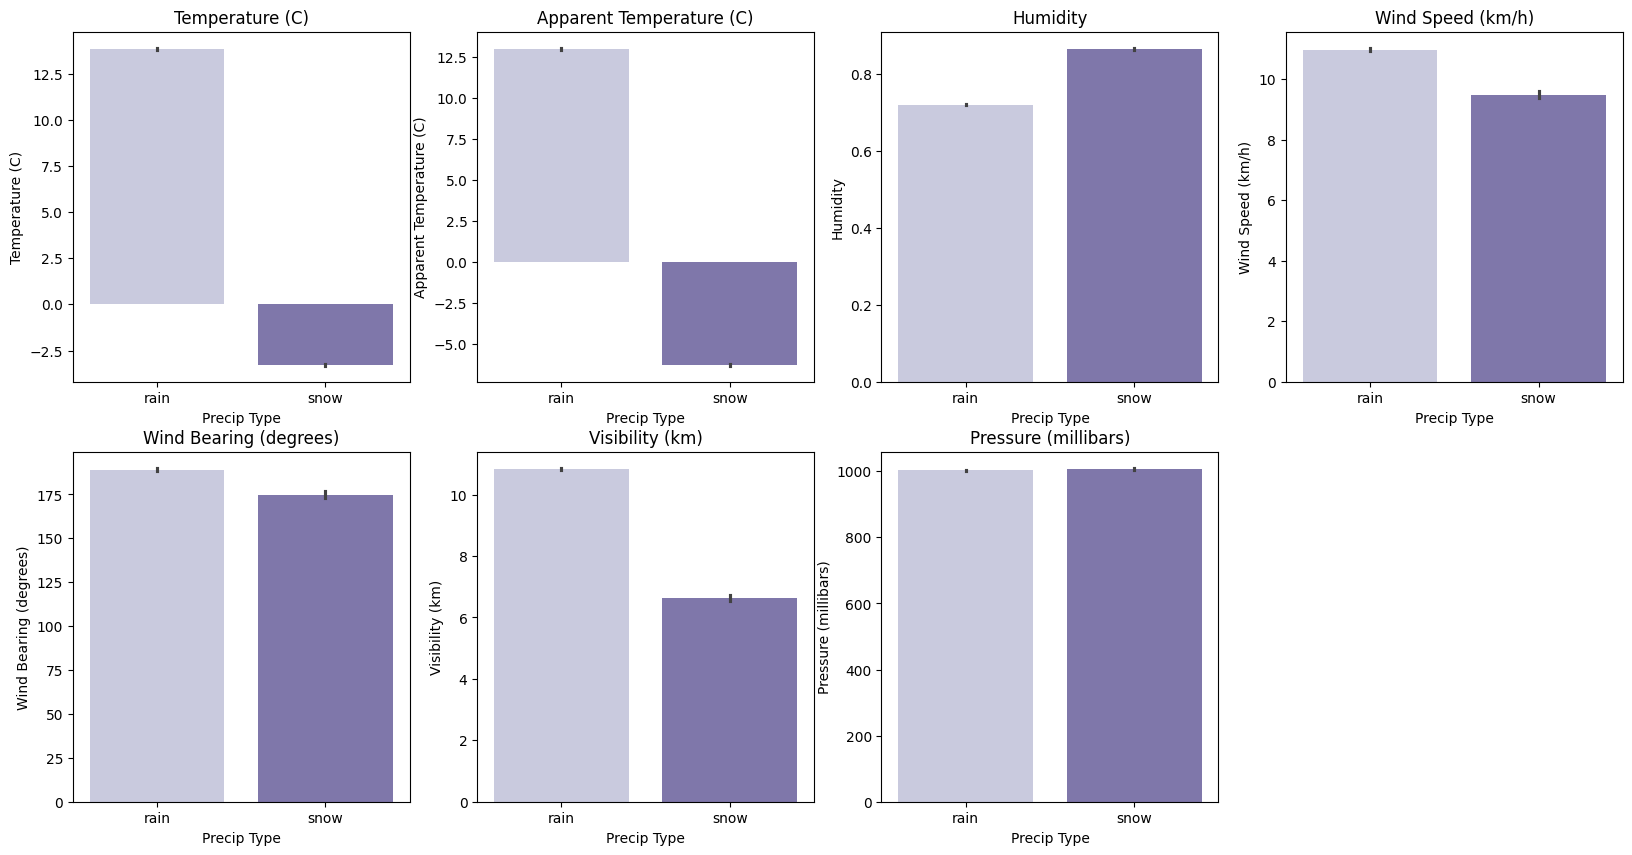

In [51]:
plt.figure(figsize=(20,10))
re=1
for i in df_new_num.columns:
    plt.subplot(2,4,re)
    sns.barplot(x=df_clean['Precip Type'], y=df_new_num[i], palette='Purples')
    re+=1
    plt.title(i)
    
plt.show()

#### Observations on Snow vs Rain

- **Temperature & Apparent Temperature:**  
  - Lower on snowy days compared to rainy days.

- **Average Humidity:**  
  - Higher on snowy days.

- **Average Wind Speed:**  
  - Lower on snowy days compared to rainy days.

- **Average Visibility:**  
  - Lower on snowy days compared to rainy days.

- **Average Pressure:**  
  - No significant difference between snowy and rainy days.


### 3.2.3 Summary vs Other Variables

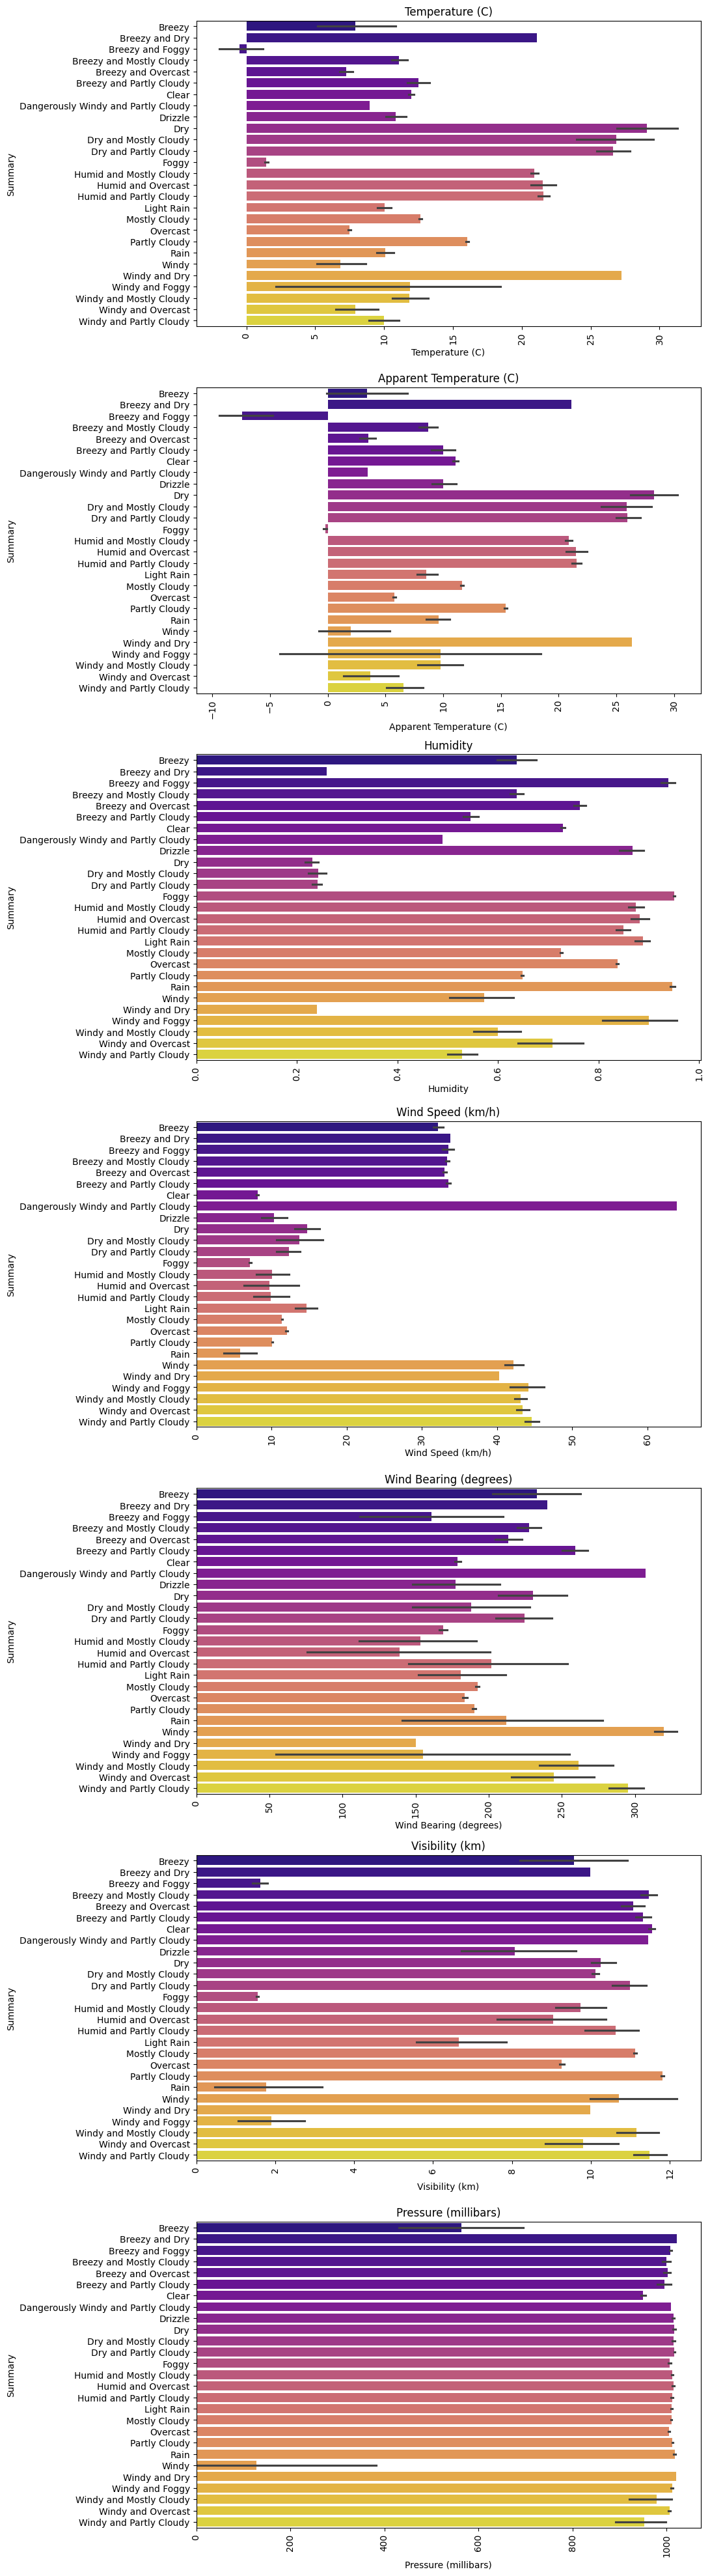

<Figure size 640x480 with 0 Axes>

In [52]:
# plotting summary vs all numerical variables 
plt.figure(figsize=(10,50))
re=1
for i in df_new_num.columns:
    plt.subplot(7,1,re)
    sns.barplot(y=df_clean['Summary'], x=df_new_num[i],palette='plasma')
    re+=1
    plt.title(i)
    plt.xticks(rotation=90)
    
plt.show()
plt.tight_layout()

#### Observations

- **Temperature:**  
  - Highest on dry days.  
  - Lowest on foggy and breezy days.

- **Humidity:**  
  - High on foggy days.

- **Wind Speed:**  
  - High on dangerously windy and partially cloudy days.

- **Visibility:**  
  - Low on foggy days.

- **Pressure:**  
  - Low on windy and breezy days.


### 3.2.4 Correlation heatmap with only numerical columns

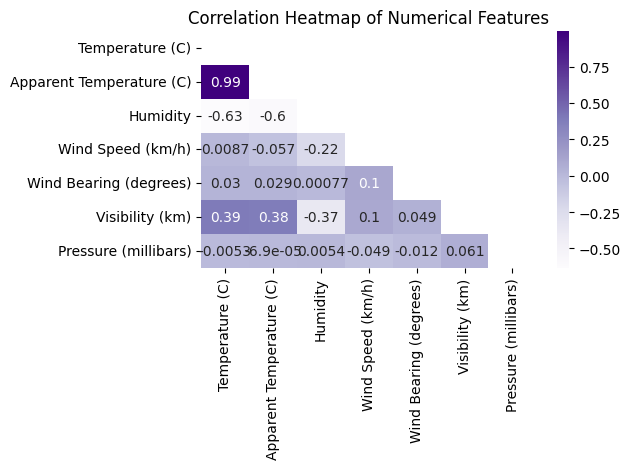

In [53]:
# correlation heatmap with only numerical columns
numerical_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, mask=np.triu(numerical_df.corr()), cmap='Purples')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

#### Correlation Summary

#### Extremely Strong Positive Correlation
- **Temperature (C) & Apparent Temperature (C): 0.99**  
  Almost perfectly linked; when one goes up, the other goes up too.

#### Strong Negative Correlation
- **Temperature (C) & Humidity: -0.63**  
  As temperature rises, humidity usually drops, and vice versa.

#### Moderate Positive Correlations
- **Temperature (C) & Visibility (km): 0.39**  
- **Apparent Temperature (C) & Visibility (km): 0.38**  
  Warmer weather tends to slightly improve visibility.

#### Weak or Negligible Correlations
- **Wind Speed (km/h) & Humidity: 0.22** (weak positive)  
- **Pressure (millibars)**: almost no correlation with other features; fairly independent.


## 4.Feature Engineering & Encoding

In [54]:

df_clean['Month'] = df_clean['Formatted Date'].dt.month
df_clean['Hour'] = df_clean['Formatted Date'].dt.hour
df_clean.drop('Formatted Date', axis=1, inplace=True)

# Drop highly correlated feature
df_clean.drop('Apparent Temperature (C)', axis=1, inplace=True)

# Encode Precip Type (0 for rain, 1 for snow)
df_clean['Precip Type'] = df_clean['Precip Type'].map({'rain': 0, 'snow': 1})

# Encode Summary (One Hot Encoding)
df_clean = pd.get_dummies(df_clean, columns=['Summary'], drop_first=True)


print(f"Data Shape: {df_clean.shape}")
df_clean.head()

Data Shape: (95912, 35)


,Precip Type,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Month,Hour,Summary_Breezy and Dry,Summary_Breezy and Foggy,Summary_Breezy and Mostly Cloudy,Summary_Breezy and Overcast,Summary_Breezy and Partly Cloudy,Summary_Clear,Summary_Dangerously Windy and Partly Cloudy,Summary_Drizzle,Summary_Dry,Summary_Dry and Mostly Cloudy,Summary_Dry and Partly Cloudy,Summary_Foggy,Summary_Humid and Mostly Cloudy,Summary_Humid and Overcast,Summary_Humid and Partly Cloudy,Summary_Light Rain,Summary_Mostly Cloudy,Summary_Overcast,Summary_Partly Cloudy,Summary_Rain,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy
0,0,9.472222,0.89,14.1197,251.0,15.8263,1015.13,3,22,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,0,9.355556,0.86,14.2646,259.0,15.8263,1015.63,3,23,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,0,9.377778,0.89,3.9284,204.0,14.9569,1015.94,4,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,0,8.288889,0.83,14.1036,269.0,15.8263,1016.41,4,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,0,8.755556,0.83,11.0446,259.0,15.8263,1016.51,4,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


## 5. Feature Selection

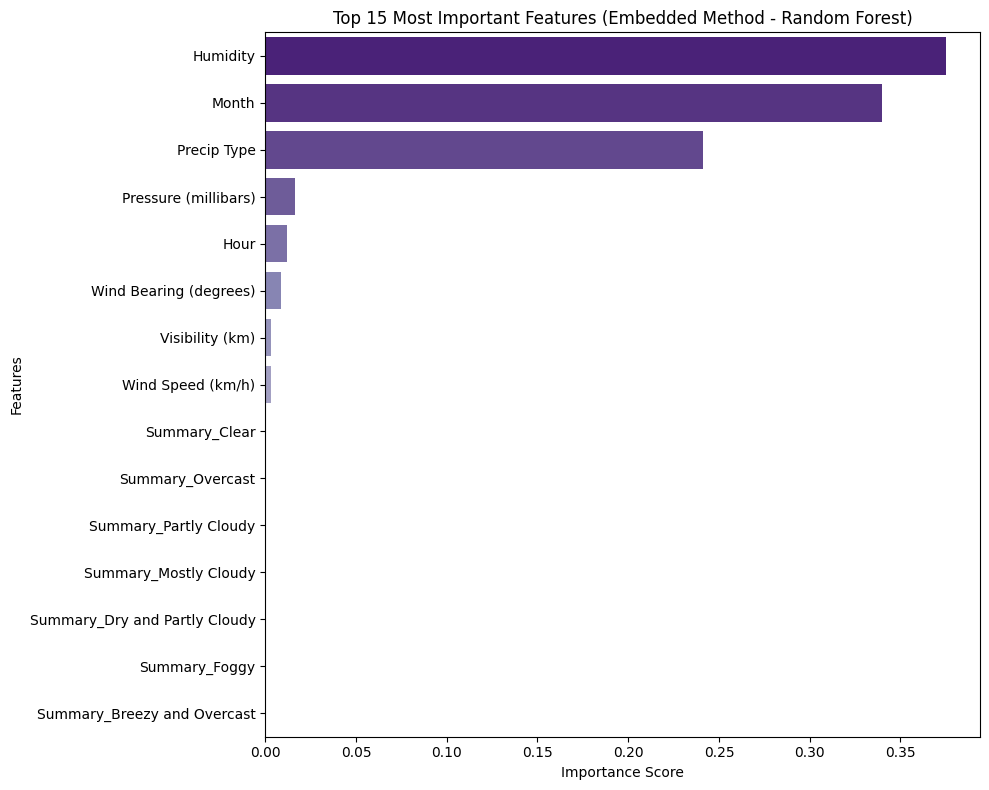

Features with very low importance (< 0.01):
['Wind Bearing (degrees)', 'Visibility (km)', 'Wind Speed (km/h)', 'Summary_Clear', 'Summary_Overcast', 'Summary_Partly Cloudy', 'Summary_Mostly Cloudy', 'Summary_Dry and Partly Cloudy', 'Summary_Foggy', 'Summary_Breezy and Overcast', 'Summary_Dry', 'Summary_Breezy and Mostly Cloudy', 'Summary_Breezy and Partly Cloudy', 'Summary_Dry and Mostly Cloudy', 'Summary_Humid and Mostly Cloudy', 'Summary_Windy and Mostly Cloudy', 'Summary_Windy and Overcast', 'Summary_Windy and Partly Cloudy', 'Summary_Breezy and Foggy', 'Summary_Drizzle', 'Summary_Humid and Overcast', 'Summary_Humid and Partly Cloudy', 'Summary_Light Rain', 'Summary_Dangerously Windy and Partly Cloudy', 'Summary_Breezy and Dry', 'Summary_Rain', 'Summary_Windy', 'Summary_Windy and Dry', 'Summary_Windy and Foggy']


In [55]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Define Features (X) and Target (y)
X = df_clean.drop('Temperature (C)', axis=1)
y = df_clean['Temperature (C)']

rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# Get feature importances
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='Purples_r')
plt.title('Top 15 Most Important Features (Embedded Method - Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

low_importance = feature_importance_df[feature_importance_df['Importance'] < 0.01]
print("Features with very low importance (< 0.01):")
print(low_importance['Feature'].tolist())

In [56]:
threshold = 0.005
features_to_keep = feature_importance_df[feature_importance_df['Importance'] >= threshold]['Feature'].tolist()
features_to_drop = feature_importance_df[feature_importance_df['Importance'] < threshold]['Feature'].tolist()

print(f"Number of features to keep: {len(features_to_keep)}")
print(f"Number of features to drop: {len(features_to_drop)}")
print("-" * 30)
print("Features being dropped:", features_to_drop)

df_final = df_clean[features_to_keep + ['Temperature (C)']]

print(f"Final Shape of the dataset: {df_final.shape}")
df_final.head()

Number of features to keep: 6
Number of features to drop: 28
------------------------------
Features being dropped: ['Visibility (km)', 'Wind Speed (km/h)', 'Summary_Clear', 'Summary_Overcast', 'Summary_Partly Cloudy', 'Summary_Mostly Cloudy', 'Summary_Dry and Partly Cloudy', 'Summary_Foggy', 'Summary_Breezy and Overcast', 'Summary_Dry', 'Summary_Breezy and Mostly Cloudy', 'Summary_Breezy and Partly Cloudy', 'Summary_Dry and Mostly Cloudy', 'Summary_Humid and Mostly Cloudy', 'Summary_Windy and Mostly Cloudy', 'Summary_Windy and Overcast', 'Summary_Windy and Partly Cloudy', 'Summary_Breezy and Foggy', 'Summary_Drizzle', 'Summary_Humid and Overcast', 'Summary_Humid and Partly Cloudy', 'Summary_Light Rain', 'Summary_Dangerously Windy and Partly Cloudy', 'Summary_Breezy and Dry', 'Summary_Rain', 'Summary_Windy', 'Summary_Windy and Dry', 'Summary_Windy and Foggy']
Final Shape of the dataset: (95912, 7)


,Humidity,Month,Precip Type,Pressure (millibars),Hour,Wind Bearing (degrees),Temperature (C)
0,0.89,3,0,1015.13,22,251.0,9.472222
1,0.86,3,0,1015.63,23,259.0,9.355556
2,0.89,4,0,1015.94,0,204.0,9.377778
3,0.83,4,0,1016.41,1,269.0,8.288889
4,0.83,4,0,1016.51,2,259.0,8.755556


## 6. Train Test Split

In [57]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Temperature (C)', axis=1)
y = df_final['Temperature (C)']

# 2. Split the data into Training and Testing sets
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total dataset shape: {df_final.shape}")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape} | y_test shape:  {y_test.shape}")


Total dataset shape: (95912, 7)
X_train shape: (76729, 6) | y_train shape: (76729,)
X_test shape:  (19183, 6) | y_test shape:  (19183,)


## 7. Scaling

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


## 8. Train Models

In [59]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [60]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

results_list = []

print("Training 7 models")

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Get Train Predictions & Accuracy
    train_predictions = model.predict(X_train_scaled)
    train_r2 = r2_score(y_train, train_predictions)
    
    # Get Test Predictions & Accuracy
    test_predictions = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, test_predictions)
    
    # Calculate MAE 
    mae = mean_absolute_error(y_test, test_predictions)
    
    results_list.append({
        "Model": name, 
        "Train Accuracy": round(train_r2, 4), 
        "Test Accuracy": round(test_r2, 4), 
        "MAE": round(mae, 4)
    })

final_comparison = pd.DataFrame(results_list).sort_values(by="Test Accuracy", ascending=False)


print(final_comparison.reset_index(drop=True))


Training 7 models
               Model  Train Accuracy  Test Accuracy     MAE
0            XGBoost          0.9079         0.9046  2.3369
1      Random Forest          0.9121         0.9032  2.3546
2      Decision Tree          0.9047         0.8942  2.4389
3                KNN          0.9252         0.8864  2.5162
4  Linear Regression          0.5964         0.6002  4.9846
5   Ridge Regression          0.5964         0.6002  4.9846
6   Lasso Regression          0.5687         0.5724  5.1950


## 9. Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

#Tuning XGBoost

# Parameters to test
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=3, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

print(f"Best XGBoost Score: {xgb_grid.best_score_:.4f}")
print(f"Best XGBoost Params: {xgb_grid.best_params_}")

Best XGBoost Score: 0.9129
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [62]:
from sklearn.ensemble import RandomForestRegressor
#Tuning Random Forest

# Parameters to test
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best Random Forest Score: {rf_grid.best_score_:.4f}")
print(f"Best Random Forest Params: {rf_grid.best_params_}")

Best Random Forest Score: 0.9162
Best Random Forest Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


In [63]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# Extract the best versions of the models
best_xgb_tuned = xgb_grid.best_estimator_
best_rf_tuned = rf_grid.best_estimator_

final_comparison_list = []
tuned_models = {"Tuned XGBoost": best_xgb_tuned, "Tuned Random Forest": best_rf_tuned}

for name, model in tuned_models.items():
    # Calculate Train & Test R2
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_preds = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, test_preds)
    
    # Calculate MAE
    mae = mean_absolute_error(y_test, test_preds)
    
    final_comparison_list.append({
        "Model": name,
        "Train Accuracy": round(train_r2, 4),
        "Test Accuracy": round(test_r2, 4),
        "MAE": round(mae, 4)
    })

final_tuning_df = pd.DataFrame(final_comparison_list).sort_values(by="Test Accuracy", ascending=False)

print(final_tuning_df.reset_index(drop=True))

                 Model  Train Accuracy  Test Accuracy     MAE
0  Tuned Random Forest          0.9788         0.9200  2.0858
1        Tuned XGBoost          0.9305         0.9149  2.1865


In [ ]:
import joblib

joblib.dump(best_rf_tuned, 'best_random_forest_model.pkl')

joblib.dump(scaler, 'scaler.pkl') 


['scaler.pkl']